# CITS4012 Natural Language Processing Individual Assignment

## Biomedical Abstract Classification

**Student ID:** Your Student ID  
**Submission:** September 2026

Medical abstract classification looks straightforward until vocabulary coverage, label imbalance, and data leakage start pulling the evaluation in different directions. This study keeps those risks visible. A PyTorch LSTM is used to compare a corpus-trained Word2Vec representation with a biomedical pretrained embedding, UMNSRS provides an intrinsic check, and BC5CDR entities test whether explicit domain knowledge adds anything beyond the token sequence. The notebook closes with a portable Colab inference form rather than a model that only works in the training session.

### Experimental protocol

The official training set is split once, stratified by condition, into an 80% fitting partition and a 20% validation partition. The test set stays sealed until the architecture and training policy are fixed. That boundary matters more than it may seem: repeated glances at test performance quietly turn a test set into another validation set. Every controlled comparison shares the split, vocabulary, truncation policy, optimiser, class weights, epoch budget, and random seed.

## Runtime and dependencies

In [1]:
import importlib.util, subprocess, sys

packages = {
    "gdown": "gdown", "gensim": "gensim>=4.4.0", "pandas": "pandas",
    "scipy": "scipy", "sklearn": "scikit-learn", "torch": "torch",
    "spacy": "spacy==3.7.5", "matplotlib": "matplotlib", "seaborn": "seaborn"
}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

model_urls = {
    "en_core_sci_md": "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz",
    "en_ner_bc5cdr_md": "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz"
}
for module, url in model_urls.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", url])
print("Environment ready")

Environment ready


In [2]:
import base64, copy, gzip, io, random, re, warnings
from collections import Counter
from pathlib import Path

import gdown, matplotlib.pyplot as plt, numpy as np, pandas as pd, seaborn as sns, spacy, torch
import torch.nn as nn
from gensim.models import Word2Vec
from scipy.stats import spearmanr
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 4012
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device={device}")

PyTorch 2.14.0; device=mps


### Data and integrity checks

The notebook downloads the four official files through the fixed Google Drive IDs published with the assignment. They are runtime inputs, not submission artefacts. Schema, missing values, and label coverage are checked before modelling; letting a malformed CSV fail halfway through training is an avoidable and surprisingly common waste of time.

In [3]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
files = {
    "medical_tc_labels.csv": "1gJxXt_H7eGh-XbB5pS0L7jmcz4HbTGkx",
    "medical_tc_test.csv": "18Nxoxgr5xqqtDiDwSIBl-l_4JG-Uam3o",
    "medical_tc_train.csv": "1rJlKpdDuDjF03ZytOQxLGMSx5OVh2wtR",
    "umnsrs_similarity_mod.csv": "1DZxOayRveumzBTIS3sB0VQXmfSx9EC6t"
}
for name, file_id in files.items():
    path = DATA_DIR / name
    if not path.exists():
        gdown.download(id=file_id, output=str(path), quiet=False)

labels_df = pd.read_csv(DATA_DIR / "medical_tc_labels.csv")
train_df = pd.read_csv(DATA_DIR / "medical_tc_train.csv")
test_df = pd.read_csv(DATA_DIR / "medical_tc_test.csv")
umnsrs_df = pd.read_csv(DATA_DIR / "umnsrs_similarity_mod.csv")
assert train_df.columns.tolist() == test_df.columns.tolist() == ["condition_label", "medical_abstract"]
assert not train_df.isna().any().any() and not test_df.isna().any().any()
assert set(train_df.condition_label) == set(test_df.condition_label) == set(labels_df.condition_label)
display(pd.DataFrame({"dataset": ["training", "test", "UMNSRS"], "rows": [len(train_df), len(test_df), len(umnsrs_df)]}))
display(labels_df)

,dataset,rows
0,training,11550
1,test,2883
2,UMNSRS,449


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


In [4]:
fit_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["condition_label"]
)
fit_df = train_df.iloc[fit_idx].reset_index(drop=True)
val_df = train_df.iloc[val_idx].reset_index(drop=True)
split_distribution = pd.concat({
    "fit": fit_df.condition_label.value_counts(normalize=True).sort_index(),
    "validation": val_df.condition_label.value_counts(normalize=True).sort_index(),
    "test": test_df.condition_label.value_counts(normalize=True).sort_index()
}, axis=1)
split_distribution.index = split_distribution.index.map(dict(zip(labels_df.condition_label, labels_df.condition_name)))
display(split_distribution.round(3))
print(f"Fit={len(fit_df):,}; validation={len(val_df):,}; untouched test={len(test_df):,}")

,fit,validation,test
condition_label,,,
neoplasms,0.219,0.219,0.219
digestive system diseases,0.103,0.103,0.104
nervous system diseases,0.133,0.133,0.134
cardiovascular diseases,0.211,0.211,0.211
general pathological conditions,0.333,0.333,0.333


Fit=9,240; validation=2,310; untouched test=2,883


## Task 1 - Corpus-trained word embedding

### Preprocessing choices

Only the fitting partition contributes to Word2Vec. Text is lower-cased and tokenised with a deterministic expression that retains alphabetic terms, internal hyphens or apostrophes, and numeric measurements. Standalone punctuation is discarded. I keep stop words because Word2Vec learns from local context, not from a bag-of-keywords view. Stemming is also avoided; collapsing biomedical surface forms can erase distinctions that are useful later.

### A small, controlled search

Three 200-dimensional candidates are enough to answer the useful question here: does the corpus favour CBOW or skip-gram, and does skip-gram benefit from a wider window? Dimension, minimum count, negative sampling, epochs, and seed remain fixed. This is deliberately modest. A large hyperparameter sweep on UMNSRS would make the intrinsic result look more certain than it is, while adding little insight.

In [5]:
TOKEN_PATTERN = re.compile(r"[a-z]+(?:[-'][a-z]+)?|\d+(?:\.\d+)?")

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text).lower())

fit_tokens = [tokenize(text) for text in fit_df.medical_abstract]
val_tokens = [tokenize(text) for text in val_df.medical_abstract]
test_tokens = [tokenize(text) for text in test_df.medical_abstract]
lengths = np.array([len(tokens) for tokens in fit_tokens])
display(pd.Series(lengths).describe(percentiles=[0.50, 0.90, 0.95, 0.99]).to_frame("tokens per abstract").round(1))
print("Example tokens:", fit_tokens[0][:30])

,tokens per abstract
count,9240.0
mean,181.8
std,77.8
min,25.0
50%,177.0
90%,278.0
95%,309.0
99%,386.0
max,606.0


Example tokens: ['premalignant', 'lesions', 'role', 'of', 'antioxidant', 'vitamins', 'and', 'beta-carotene', 'in', 'risk', 'reduction', 'and', 'prevention', 'of', 'malignant', 'transformation', 'epidemiological', 'studies', 'have', 'shown', 'that', 'diets', 'rich', 'in', 'one', 'or', 'more', 'antioxidant', 'nutrients', 'may']


In [6]:
embedding_specs = {"CBOW-w5": (0, 5), "SG-w5": (1, 5), "SG-w10": (1, 10)}
self_embeddings = {
    name: Word2Vec(
        fit_tokens, vector_size=200, window=window, min_count=2, sg=sg,
        negative=10, sample=1e-4, workers=1, seed=SEED, epochs=8
    )
    for name, (sg, window) in embedding_specs.items()
}
display(pd.DataFrame([
    {"candidate": name, "architecture": "skip-gram" if sg else "CBOW", "window": window,
     "dimensions": model.vector_size, "vocabulary": len(model.wv)}
    for (name, (sg, window)), model in zip(embedding_specs.items(), self_embeddings.values())
]))
for name, model in self_embeddings.items():
    print(f"{name}: disease ->", ", ".join(word for word, _ in model.wv.most_similar("disease", topn=5)))

,candidate,architecture,window,dimensions,vocabulary
0,CBOW-w5,CBOW,5,200,27268
1,SG-w5,skip-gram,5,200,27268
2,SG-w10,skip-gram,10,200,27268


CBOW-w5: disease -> end-stage, crohn's, kawasaki, cerebrovascular, alzheimer's
SG-w5: disease -> extraintestinal, acne, angiographically-proven, plethora, editorial
SG-w10: disease -> ganglioneuromatosis, satisfying, copenhagen, polyostotic, angiographically-proven


A minimum count of two removes one-off noise without throwing away most clinical terminology. Ten negative samples are a sensible rule of thumb for a corpus of this size. One worker sacrifices some speed for reproducibility, and eight epochs give the models repeated exposure without turning a teaching notebook into an overnight job.

## Task 2 - Pretrained biomedical word embedding

The external representation is the 200-dimensional static vector table from AllenAI's **scispaCy `en_core_sci_md` 0.5.4** model. It contains 50,000 vector rows and was built for scientific and biomedical language. A general-news embedding would be an easy baseline to obtain, but it would be the wrong professional choice for disease names, chemicals, procedures, and anatomy.

References:

- [scispaCy models and release downloads](https://allenai.github.io/scispacy/)
- [Neumann et al. (2019), ScispaCy: Fast and Robust Models for Biomedical Natural Language Processing](https://aclanthology.org/W19-5034/)

Only the vocabulary and vector table are loaded. Running the parser and NER pipeline for a static lookup would add latency with no benefit. Task 5 uses a separate model trained for entity recognition.

In [7]:
pretrained_nlp = spacy.load(
    "en_core_sci_md",
    disable=["tok2vec", "tagger", "parser", "ner", "lemmatizer", "attribute_ruler"]
)
print("Model:", pretrained_nlp.meta["name"], pretrained_nlp.meta["version"])
print("Static vector table:", pretrained_nlp.vocab.vectors.shape)
for term in ["neoplasm", "cardiovascular", "heparin", "gastrointestinal"]:
    lexeme = pretrained_nlp.vocab[term]
    print(term, "has_vector=", lexeme.has_vector, "dimension=", len(lexeme.vector))

Model: core_sci_md 0.5.4
Static vector table: (50000, 200)
neoplasm has_vector= True dimension= 200
cardiovascular has_vector= True dimension= 200
heparin has_vector= True dimension= 200
gastrointestinal has_vector= True dimension= 200


## Task 3 - Intrinsic evaluation with UMNSRS

Each UMNSRS concept is passed through the training tokenizer. Multi-word concepts are represented by the mean of their available token vectors; a concept is OOV only when none of its tokens has a vector. Cosine similarity is then compared with the human score using Spearman's rank correlation.

There is a quiet fairness trap here. Correlations calculated over different subsets are not directly comparable, because the easier model may simply skip harder terms. The notebook therefore reports each embedding on all pairs it can score and treats the exact intersection as the primary comparison. No random OOV vector is allowed into the intrinsic evaluation.

In [8]:
def concept_vector(text, lookup):
    vectors = [vector for token in tokenize(text) if (vector := lookup(token)) is not None]
    return np.mean(vectors, axis=0) if vectors else None

def intrinsic_scores(lookup):
    scores, valid = [], []
    for row in umnsrs_df.itertuples():
        left, right = concept_vector(row.text_1, lookup), concept_vector(row.text_2, lookup)
        ok = left is not None and right is not None
        valid.append(ok)
        scores.append(float(np.dot(left, right) / (np.linalg.norm(left) * np.linalg.norm(right))) if ok else np.nan)
    valid, scores = np.asarray(valid), np.asarray(scores)
    rho, p = spearmanr(umnsrs_df.loc[valid, "label"], scores[valid])
    return {"valid": valid, "similarities": scores, "rho": rho, "p": p}

lookups = {
    **{name: (lambda token, wv=model.wv: wv[token] if token in wv else None) for name, model in self_embeddings.items()},
    "scispaCy-md": lambda token: pretrained_nlp.vocab[token].vector if pretrained_nlp.vocab[token].has_vector else None
}
intrinsic = {name: intrinsic_scores(lookup) for name, lookup in lookups.items()}
display(pd.DataFrame([
    {"embedding": name, "scored_pairs": int(result["valid"].sum()), "coverage": result["valid"].mean(),
     "Spearman_rho_all_scorable": result["rho"], "p_value": result["p"]}
    for name, result in intrinsic.items()
]).round(4))

,embedding,scored_pairs,coverage,Spearman_rho_all_scorable,p_value
0,CBOW-w5,229,0.5100,0.2356,0.0003
1,SG-w5,229,0.5100,0.3787,0.0000
2,SG-w10,229,0.5100,0.4740,0.0000
3,scispaCy-md,432,0.9621,0.4957,0.0000


In [9]:
common_results = []
for name in embedding_specs:
    common = intrinsic[name]["valid"] & intrinsic["scispaCy-md"]["valid"]
    common_results.append({
        "self_candidate": name,
        "common_pairs": int(common.sum()),
        "self_rho": spearmanr(umnsrs_df.loc[common, "label"], intrinsic[name]["similarities"][common]).statistic,
        "pretrained_rho": spearmanr(umnsrs_df.loc[common, "label"], intrinsic["scispaCy-md"]["similarities"][common]).statistic
    })
common_results = pd.DataFrame(common_results)
display(common_results.round(4))
best_self_name = common_results.loc[common_results.self_rho.idxmax(), "self_candidate"]
best_self_embedding = self_embeddings[best_self_name]
print("Selected self-trained embedding:", best_self_name)

,self_candidate,common_pairs,self_rho,pretrained_rho
0,CBOW-w5,229,0.2356,0.5323
1,SG-w5,229,0.3787,0.5323
2,SG-w10,229,0.4740,0.5323


Selected self-trained embedding: SG-w10


### What the intrinsic results say

SG-w10 is the strongest corpus-trained candidate (rho = 0.4740), ahead of SG-w5 (0.3787) and CBOW-w5 (0.2356). The wider window is doing useful work: biomedical similarity often reflects topic-level context rather than immediate syntax. SG-w10 is carried into the classifier.

Coverage tells the other half of the story. The corpus-trained vocabulary scores 229 of 449 pairs (51.00%); scispaCy scores 432 (96.21%). On the same 229 pairs, scispaCy reaches rho = 0.5323 against 0.4740 for SG-w10, an absolute lead of 0.0583. Both correlations are significant at p < 0.001. Averaging known components rescues some multi-word concepts, but it cannot recover phrase-specific meaning or terms whose components are all absent.

## Task 4 - Medical abstract classification

### Controls that make the comparison credible

The vocabulary comes from the fitting partition and is capped at 15,000 tokens. Abstracts longer than 192 tokens keep the first 96 and last 96. This compromise is practical and clinically sensible: objectives tend to appear early, while conclusions often sit at the end. `<PAD>` is fixed at zero and unseen tokens use `<UNK>`.

Both embedding matrices use 200 dimensions and remain trainable. Missing source vectors receive the same seeded small-random initialisation. Class-weighted cross-entropy offsets the label imbalance. Freezing one embedding, changing the optimiser for another, or giving one model more epochs would make the comparison easier to run but harder to defend.

### LSTM configuration

The architecture search stays narrow: a 64-unit unidirectional LSTM, a 64-unit bidirectional LSTM, and a 96-unit bidirectional LSTM. Validation macro-F1 decides among them. The embedding comparison begins only after that choice is locked.

In [10]:
MAX_VOCAB, MAX_LEN = 15000, 192
counts = Counter(token for document in fit_tokens for token in document)
vocabulary = [token for token, count in counts.most_common() if count >= 2][:MAX_VOCAB - 2]
token_to_idx = {"<PAD>": 0, "<UNK>": 1, **{token: index + 2 for index, token in enumerate(vocabulary)}}
label_to_index = {label: index for index, label in enumerate(sorted(labels_df.condition_label))}
index_to_name = dict(enumerate(labels_df.sort_values("condition_label").condition_name))

def encode_documents(documents):
    encoded = np.zeros((len(documents), MAX_LEN), dtype=np.int64)
    lengths = np.empty(len(documents), dtype=np.int64)
    for row, tokens in enumerate(documents):
        selected = tokens if len(tokens) <= MAX_LEN else tokens[:MAX_LEN // 2] + tokens[-MAX_LEN // 2:]
        indices = [token_to_idx.get(token, 1) for token in selected]
        encoded[row, :len(indices)] = indices
        lengths[row] = len(indices)
    return encoded, lengths

fit_x, fit_lengths = encode_documents(fit_tokens)
val_x, val_lengths = encode_documents(val_tokens)
test_x, test_lengths = encode_documents(test_tokens)
y_fit = fit_df.condition_label.map(label_to_index).to_numpy()
y_val = val_df.condition_label.map(label_to_index).to_numpy()
y_test = test_df.condition_label.map(label_to_index).to_numpy()
print(f"Vocabulary size={len(token_to_idx):,}; maximum sequence length={MAX_LEN}")

Vocabulary size=15,000; maximum sequence length=192


In [11]:
def embedding_matrix(lookup):
    matrix = np.random.default_rng(SEED).normal(0, 0.05, (len(token_to_idx), 200)).astype(np.float32)
    matrix[0] = 0
    found = 0
    for token, index in token_to_idx.items():
        vector = lookup(token) if index > 1 else None
        if vector is not None:
            matrix[index], found = vector, found + 1
    return matrix, found / (len(token_to_idx) - 2)

self_matrix, self_coverage = embedding_matrix(lambda token: best_self_embedding.wv[token] if token in best_self_embedding.wv else None)
pretrained_matrix, pretrained_coverage = embedding_matrix(
    lambda token: pretrained_nlp.vocab[token].vector if pretrained_nlp.vocab[token].has_vector else None
)
display(pd.DataFrame({
    "embedding": [best_self_name, "scispaCy-md"],
    "classifier_vocabulary_coverage": [self_coverage, pretrained_coverage],
    "dimensions": [200, 200]
}).round(4))

,embedding,classifier_vocabulary_coverage,dimensions
0,SG-w10,1.0000,200
1,scispaCy-md,0.9654,200


In [12]:
class LSTMClassifier(nn.Module):
    def __init__(self, matrix, hidden_size, bidirectional, dropout, feature_dim=0):
        super().__init__()
        weights = torch.as_tensor(matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(weights, freeze=False, padding_idx=0)
        self.lstm = nn.LSTM(200, hidden_size, batch_first=True, bidirectional=bidirectional)
        width = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(width + feature_dim, hidden_size)
        self.output = nn.Linear(hidden_size, len(index_to_name))
        self.bidirectional = bidirectional

    def forward(self, tokens, lengths, features):
        packed = pack_padded_sequence(self.dropout(self.embedding(tokens)), lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        state = torch.cat((hidden[-2], hidden[-1]), 1) if self.bidirectional else hidden[-1]
        if features.shape[1]:
            state = torch.cat((state, features), 1)
        return self.output(self.dropout(torch.relu(self.hidden(state))))

def make_loader(tokens, lengths, labels, features=None, shuffle=False):
    features = np.zeros((len(labels), 0), np.float32) if features is None else features
    dataset = TensorDataset(
        torch.tensor(tokens), torch.tensor(lengths), torch.tensor(labels), torch.tensor(features)
    )
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(dataset, batch_size=128, shuffle=shuffle, generator=generator)

In [13]:
counts = np.bincount(y_fit, minlength=len(index_to_name))
class_weights = torch.tensor(len(y_fit) / (len(index_to_name) * counts), dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def evaluate_model(model, loader):
    model.eval(); losses, predictions, targets = [], [], []
    with torch.no_grad():
        for tokens, lengths, labels, features in loader:
            tokens, labels, features = tokens.to(device), labels.to(device), features.to(device)
            logits = model(tokens, lengths, features)
            losses.append(criterion(logits, labels).item())
            predictions.extend(logits.argmax(1).cpu().numpy()); targets.extend(labels.cpu().numpy())
    predictions, targets = np.asarray(predictions), np.asarray(targets)
    return {
        "loss": np.mean(losses), "accuracy": accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro"),
        "weighted_f1": f1_score(targets, predictions, average="weighted"),
        "predictions": predictions, "targets": targets
    }

def train_model(matrix, config, train_features=None, validation_features=None, max_epochs=5, patience=2):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    model = LSTMClassifier(matrix, **config, feature_dim=0 if train_features is None else train_features.shape[1]).to(device)
    train_loader = make_loader(fit_x, fit_lengths, y_fit, train_features, True)
    validation_loader = make_loader(val_x, val_lengths, y_val, validation_features)
    optimiser = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    best_state, best_f1, stale, history = None, -1, 0, []
    for epoch in range(1, max_epochs + 1):
        model.train(); losses = []
        for tokens, lengths, labels, features in train_loader:
            tokens, labels, features = tokens.to(device), labels.to(device), features.to(device)
            optimiser.zero_grad(set_to_none=True)
            loss = criterion(model(tokens, lengths, features), labels)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimiser.step()
            losses.append(loss.item())
        validation = evaluate_model(model, validation_loader)
        history.append({"epoch": epoch, "train_loss": np.mean(losses), "val_loss": validation["loss"], "val_macro_f1": validation["macro_f1"]})
        if validation["macro_f1"] > best_f1 + 1e-4:
            best_state, best_f1, stale = copy.deepcopy(model.state_dict()), validation["macro_f1"], 0
        else:
            stale += 1
        if stale >= patience:
            break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), evaluate_model(model, validation_loader)

In [14]:
architecture_configs = {
    "UniLSTM-64": {"hidden_size": 64, "bidirectional": False, "dropout": 0.30},
    "BiLSTM-64": {"hidden_size": 64, "bidirectional": True, "dropout": 0.30},
    "BiLSTM-96": {"hidden_size": 96, "bidirectional": True, "dropout": 0.40}
}
rows = []
for name, config in architecture_configs.items():
    model, history, validation = train_model(self_matrix, config, max_epochs=3, patience=1)
    rows.append({"configuration": name, "epochs_run": len(history), "best_epoch": history.val_macro_f1.idxmax() + 1,
                 "validation_accuracy": validation["accuracy"], "validation_macro_f1": validation["macro_f1"]})
    print(name, "complete")
architecture_results = pd.DataFrame(rows).sort_values("validation_macro_f1", ascending=False)
display(architecture_results.round(4))
selected_config_name = architecture_results.iloc[0].configuration
selected_config = architecture_configs[selected_config_name]
print("Selected architecture:", selected_config_name, selected_config)

UniLSTM-64 complete


BiLSTM-64 complete


BiLSTM-96 complete


,configuration,epochs_run,best_epoch,validation_accuracy,validation_macro_f1
1,BiLSTM-64,3,3,0.5654,0.5600
2,BiLSTM-96,3,3,0.5489,0.5479
0,UniLSTM-64,3,3,0.5277,0.4981


Selected architecture: BiLSTM-64 {'hidden_size': 64, 'bidirectional': True, 'dropout': 0.3}


In [15]:
comparison_models, comparison_validation = {}, {}
for name, matrix in {"Self-trained": self_matrix, "Pretrained biomedical": pretrained_matrix}.items():
    model, history, validation = train_model(matrix, selected_config, max_epochs=5, patience=2)
    comparison_models[name], comparison_validation[name] = model, validation
    print(name, "best validation macro-F1:", round(validation["macro_f1"], 4))

test_loader = make_loader(test_x, test_lengths, y_test)
comparison_test = {name: evaluate_model(model, test_loader) for name, model in comparison_models.items()}
comparison_table = pd.DataFrame([
    {"embedding": name, "validation_accuracy": comparison_validation[name]["accuracy"],
     "validation_macro_f1": comparison_validation[name]["macro_f1"], "test_accuracy": result["accuracy"],
     "test_macro_f1": result["macro_f1"], "test_weighted_f1": result["weighted_f1"]}
    for name, result in comparison_test.items()
])
display(comparison_table.round(4))

Self-trained best validation macro-F1: 0.5492


Pretrained biomedical best validation macro-F1: 0.5452


,embedding,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Self-trained,0.5615,0.5492,0.5553,0.5470,0.5146
1,Pretrained biomedical,0.5463,0.5452,0.5567,0.5557,0.5385


,precision,recall,f1-score,support
neoplasms,0.5741,0.8766,0.6938,632.0000
digestive system diseases,0.4352,0.6856,0.5325,299.0000
nervous system diseases,0.5418,0.5558,0.5487,385.0000
cardiovascular diseases,0.6529,0.7529,0.6993,607.0000
general pathological conditions,0.4858,0.1781,0.2607,960.0000
accuracy,0.5553,0.5553,0.5553,0.5553
macro avg,0.5380,0.6098,0.5470,2883.0000
weighted avg,0.5426,0.5553,0.5146,2883.0000


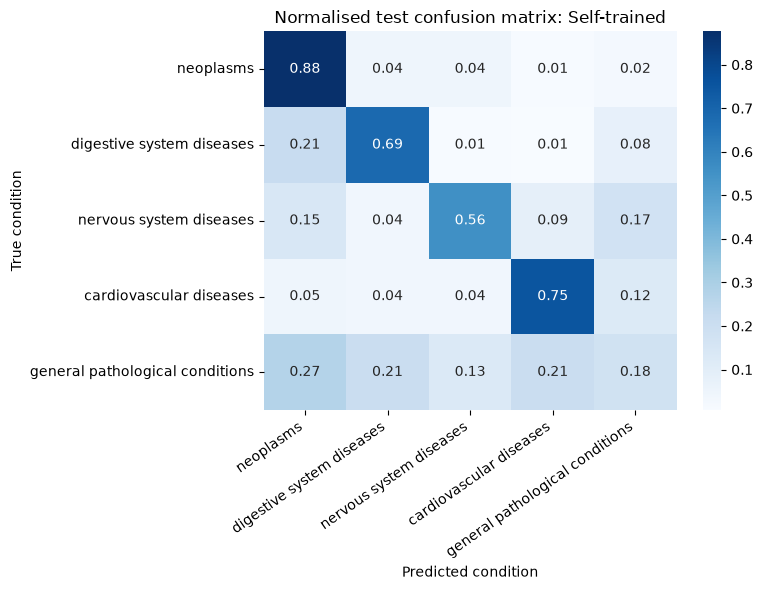

In [16]:
best_embedding_label = max(comparison_validation, key=lambda name: comparison_validation[name]["macro_f1"])
result = comparison_test[best_embedding_label]
display(pd.DataFrame(classification_report(
    result["targets"], result["predictions"], target_names=list(index_to_name.values()),
    output_dict=True, zero_division=0
)).T.round(4))

matrix = confusion_matrix(result["targets"], result["predictions"], normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=index_to_name.values(), yticklabels=index_to_name.values())
plt.xlabel("Predicted condition"); plt.ylabel("True condition")
plt.title(f"Normalised test confusion matrix: {best_embedding_label}")
plt.xticks(rotation=35, ha="right"); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

### Reading the classification results

BiLSTM-64 leads the architecture screen with validation macro-F1 of 0.5600, compared with 0.5479 for BiLSTM-96 and 0.4981 for UniLSTM-64. Bidirectionality helps; extra capacity does not. BiLSTM-64 is therefore the cleaner choice.

Under the locked configuration, the corpus-trained embedding records validation/test macro-F1 of 0.5492/0.5470. The pretrained model records 0.5452/0.5557; test accuracy is 0.5553 versus 0.5567. Validation narrowly favours SG-w10, while the untouched test set narrowly favours scispaCy. A margin this small should not be dressed up as a decisive win. It suggests that representation choice is less important than the shared sequence model and that the ranking is sensitive to the sampled split.

The intrinsic result aligns with the pretrained model's small test advantage but not with the validation ranking. That mixed result is plausible. UMNSRS rewards broad concept similarity; the classifier rewards cues that separate five labels in this corpus. SG-w10 learns directly from these abstracts and covers the classifier vocabulary by construction, while 3.46% of the scispaCy vocabulary rows require random initialisation. scispaCy, however, brings much broader semantic coverage. These strengths pull in different directions.

The strongest class results occur for neoplasms and cardiovascular diseases. Recall for the broad *general pathological conditions* class falls to 0.1781. That label is semantically diffuse, and class weighting pushes the model to pay more attention to smaller classes. The trade-off is visible in the gap between per-class recall and aggregate accuracy, which is why macro-F1 remains the selection metric.

## Task 5 - Adding biomedical NER

The NER model is AllenAI's **scispaCy `en_ner_bc5cdr_md` 0.5.4**, trained on the BioCreative V Chemical Disease Relation corpus. Its `DISEASE` and `CHEMICAL` spans match the vocabulary of diagnosis and treatment found throughout the abstracts.

References:

- [scispaCy biomedical NER releases](https://allenai.github.io/scispacy/)
- [Li et al. (2016), BioCreative V CDR task corpus](https://academic.oup.com/database/article/doi/10.1093/database/baw068/2630414)

### Feature design

Five document features are extracted: log-scaled disease count, chemical count, unique disease count, unique chemical count, and the fraction of characters covered by entities. A scaler fitted on the fitting partition standardises them before they are concatenated with the LSTM representation. Counts are intentionally conservative. They are cheap, robust, and make it easy to tell whether NER contributes signal before investing in token-level entity encoders.

In [17]:
ner_nlp = spacy.load(
    "en_ner_bc5cdr_md",
    disable=["tagger", "parser", "lemmatizer", "attribute_ruler"]
)
example_rows = []
for document_index, document in enumerate(ner_nlp.pipe(fit_df.medical_abstract.iloc[:3], batch_size=3), start=1):
    for entity in list(document.ents)[:10]:
        example_rows.append({"abstract": document_index, "entity": entity.text, "type": entity.label_})
display(pd.DataFrame(example_rows))

,abstract,entity,type
0,1,vitamins,CHEMICAL
1,1,beta-carotene,CHEMICAL
2,1,malignant transformation,DISEASE
3,1,"cancers of the lung, uterine cervix",DISEASE
4,1,gastrointestinal tract,DISEASE
5,1,cancer,DISEASE
6,1,vitamin C,CHEMICAL
7,1,dysplasia,DISEASE
8,1,vitamin C,CHEMICAL
9,1,beta-carotene,CHEMICAL


In [18]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
ner_cache = ARTIFACT_DIR / "ner_features.npz"

def entity_features(texts):
    rows = []
    for text, document in zip(texts, ner_nlp.pipe(texts, batch_size=32)):
        diseases = [entity.text.lower() for entity in document.ents if entity.label_ == "DISEASE"]
        chemicals = [entity.text.lower() for entity in document.ents if entity.label_ == "CHEMICAL"]
        rows.append([np.log1p(len(diseases)), np.log1p(len(chemicals)),
                     np.log1p(len(set(diseases))), np.log1p(len(set(chemicals))),
                     sum(entity.end_char - entity.start_char for entity in document.ents) / max(len(text), 1)])
    return np.asarray(rows, np.float32)

names, frames = ["fit", "validation", "test"], [fit_df, val_df, test_df]
expected = tuple(map(len, frames))
cached = np.load(ner_cache) if ner_cache.exists() else None
if cached is not None and tuple(len(cached[name]) for name in names) == expected:
    fit_ner_raw, val_ner_raw, test_ner_raw = (cached[name] for name in names)
else:
    fit_ner_raw, val_ner_raw, test_ner_raw = [entity_features(frame.medical_abstract.tolist()) for frame in frames]
    np.savez_compressed(ner_cache, fit=fit_ner_raw, validation=val_ner_raw, test=test_ner_raw)

ner_scaler = StandardScaler().fit(fit_ner_raw)
fit_ner, val_ner, test_ner = [ner_scaler.transform(values).astype(np.float32) for values in (fit_ner_raw, val_ner_raw, test_ner_raw)]
columns = ["log_disease", "log_chemical", "log_unique_disease", "log_unique_chemical", "entity_char_fraction"]
display(pd.DataFrame(fit_ner_raw, columns=columns).describe().round(3))

,log_disease,log_chemical,log_unique_disease,log_unique_chemical,entity_char_fraction
count,9240.000,9240.000,9240.000,9240.000,9240.000
mean,1.951,0.734,1.607,0.540,0.122
std,0.672,0.934,0.580,0.674,0.078
min,0.000,0.000,0.000,0.000,0.000
25%,1.609,0.000,1.099,0.000,0.065
50%,2.079,0.000,1.609,0.000,0.110
75%,2.398,1.386,2.079,1.099,0.164
max,3.784,3.584,3.555,2.944,0.528


In [19]:
ner_model, ner_history, ner_validation = train_model(
    pretrained_matrix, selected_config, fit_ner, val_ner, max_epochs=5, patience=2
)
ner_test = evaluate_model(ner_model, make_loader(test_x, test_lengths, y_test, test_ner))
ner_comparison = pd.DataFrame([
    {"model": "Pretrained biomedical LSTM", "validation_accuracy": comparison_validation["Pretrained biomedical"]["accuracy"],
     "validation_macro_f1": comparison_validation["Pretrained biomedical"]["macro_f1"],
     "test_accuracy": comparison_test["Pretrained biomedical"]["accuracy"],
     "test_macro_f1": comparison_test["Pretrained biomedical"]["macro_f1"]},
    {"model": "Pretrained biomedical LSTM + NER", "validation_accuracy": ner_validation["accuracy"],
     "validation_macro_f1": ner_validation["macro_f1"], "test_accuracy": ner_test["accuracy"],
     "test_macro_f1": ner_test["macro_f1"]}
])
display(ner_comparison.round(4))

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1
0,Pretrained biomedical LSTM,0.5463,0.5452,0.5567,0.5557
1,Pretrained biomedical LSTM + NER,0.5476,0.5462,0.5595,0.5607


### What NER contributes

The entity features move validation macro-F1 from 0.5452 to 0.5462 and test macro-F1 from 0.5557 to 0.5607. Test accuracy rises from 0.5567 to 0.5595. The gain is modest, but it appears on both splits. Entity density and diversity add a little information that the pretrained token sequence does not fully capture; they are not a substitute for the sequence representation.

Document counts also leave plenty on the table. They discard identity, negation, relations, and position, while BC5CDR ignores anatomical and physiological entities. Token-aligned BIO features would be the next serious experiment, but only with a separate validation design; adding a more elaborate encoder simply because it sounds richer is a reliable way to overfit a small study.

## Task 6 - Portable Google Colab inference

### Selecting and packaging the model

Deployment follows validation macro-F1, not the most attractive test number. The candidate set contains the corpus-trained baseline, pretrained baseline, and pretrained-plus-NER model. The chosen vocabulary, label map, architecture, optional NER scaler, and half-precision weights are compressed into a Base64 bundle stored inside the notebook. This keeps the one-file submission genuinely portable; there is no hidden checkpoint on a local drive.

In [20]:
deployment_candidates = {
    "Self-trained": (comparison_models["Self-trained"], comparison_validation["Self-trained"], False),
    "Pretrained biomedical": (comparison_models["Pretrained biomedical"], comparison_validation["Pretrained biomedical"], False),
    "Pretrained biomedical + NER": (ner_model, ner_validation, True)
}
selected_deployment_name = max(deployment_candidates, key=lambda name: deployment_candidates[name][1]["macro_f1"])
selected_deployment_model, selected_deployment_validation, selected_uses_ner = deployment_candidates[selected_deployment_name]
portable_state = {
    key: value.detach().cpu().half() if value.is_floating_point() else value.detach().cpu()
    for key, value in selected_deployment_model.state_dict().items()
}
bundle = {
    "state_dict": portable_state,
    "token_to_idx": token_to_idx,
    "index_to_name": index_to_name,
    "max_len": MAX_LEN,
    "config": selected_config,
    "uses_ner": selected_uses_ner,
    "scaler_mean": ner_scaler.mean_.tolist() if selected_uses_ner else None,
    "scaler_scale": ner_scaler.scale_.tolist() if selected_uses_ner else None,
    "model_name": selected_deployment_name
}
buffer = io.BytesIO()
torch.save(bundle, buffer)
bundle_b64 = base64.b64encode(gzip.compress(buffer.getvalue(), compresslevel=9)).decode("ascii")
(ARTIFACT_DIR / "inference_bundle.txt").write_text(bundle_b64)
print("Selected deployment model:", selected_deployment_name)
print("Validation macro-F1:", round(selected_deployment_validation["macro_f1"], 4))
print("Embedded bundle size:", f"{len(bundle_b64) / 1_000_000:.2f} MB")

Selected deployment model: Self-trained
Validation macro-F1: 0.5492
Embedded bundle size: 7.95 MB


### Fresh-runtime form

The two cells below are sufficient in a clean Colab runtime. The hidden setup cell restores the complete model. The form cell accepts an unseen English medical abstract, applies the same tokenisation and truncation policy, adds NER features when required, and prints the predicted condition with class probabilities.

In [1]:
import base64
import gzip
import importlib.util
import io
import re
import subprocess
import sys

if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])

import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

BUNDLE_B64 = "..."
bundle = torch.load(io.BytesIO(gzip.decompress(base64.b64decode(BUNDLE_B64))), map_location="cpu", weights_only=False)

if bundle["uses_ner"]:
    if importlib.util.find_spec("spacy") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "spacy==3.7.5"])
    if importlib.util.find_spec("en_ner_bc5cdr_md") is None:
        source = "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz"
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", source])
    import spacy
    inference_ner = spacy.load("en_ner_bc5cdr_md", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"])
else:
    inference_ner = None

class PortableLSTMClassifier(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension, hidden_size, bidirectional, dropout, feature_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dimension, hidden_size, batch_first=True, bidirectional=bidirectional)
        representation_size = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.hidden = nn.Linear(representation_size + feature_dim, hidden_size)
        self.output = nn.Linear(hidden_size, len(bundle["index_to_name"]))
        self.bidirectional = bidirectional

    def forward(self, tokens, lengths, features=None):
        embedded = self.embedding(tokens)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        representation = torch.cat((hidden[-2], hidden[-1]), dim=1) if self.bidirectional else hidden[-1]
        if features is not None and features.shape[1] > 0:
            representation = torch.cat((representation, features), dim=1)
        representation = self.dropout(torch.relu(self.hidden(representation)))
        return self.output(representation)

embedding_shape = bundle["state_dict"]["embedding.weight"].shape
feature_dim = 5 if bundle["uses_ner"] else 0
inference_model = PortableLSTMClassifier(
    embedding_shape[0],
    embedding_shape[1],
    bundle["config"]["hidden_size"],
    bundle["config"]["bidirectional"],
    bundle["config"]["dropout"],
    feature_dim
)
inference_model.load_state_dict(bundle["state_dict"])
inference_model.eval()
inference_pattern = re.compile(r"[a-z]+(?:[-'][a-z]+)?|\d+(?:\.\d+)?")

def prepare_inference(abstract):
    tokens = inference_pattern.findall(abstract.lower())
    maximum = bundle["max_len"]
    if len(tokens) > maximum:
        half = maximum // 2
        tokens = tokens[:half] + tokens[-half:]
    indices = [bundle["token_to_idx"].get(token, 1) for token in tokens] or [1]
    token_tensor = torch.tensor([indices], dtype=torch.long)
    length_tensor = torch.tensor([len(indices)], dtype=torch.long)
    if not bundle["uses_ner"]:
        return token_tensor, length_tensor, torch.zeros((1, 0), dtype=torch.float32)
    document = inference_ner(abstract)
    diseases = [entity.text.lower() for entity in document.ents if entity.label_ == "DISEASE"]
    chemicals = [entity.text.lower() for entity in document.ents if entity.label_ == "CHEMICAL"]
    covered = sum(entity.end_char - entity.start_char for entity in document.ents)
    raw = np.array([[
        np.log1p(len(diseases)),
        np.log1p(len(chemicals)),
        np.log1p(len(set(diseases))),
        np.log1p(len(set(chemicals))),
        covered / max(len(abstract), 1)
    ]], dtype=np.float32)
    scaled = (raw - np.asarray(bundle["scaler_mean"])) / np.asarray(bundle["scaler_scale"])
    return token_tensor, length_tensor, torch.tensor(scaled, dtype=torch.float32)

print("Portable model ready:", bundle["model_name"])

Portable model ready: Self-trained


In [2]:
#@title Biomedical abstract prediction
abstract_text = "A patient with progressive chest pain and shortness of breath underwent coronary angiography, which showed severe stenosis of the left anterior descending artery." #@param {type:"string"}

tokens, lengths, features = prepare_inference(abstract_text)
with torch.no_grad():
    probabilities = torch.softmax(inference_model(tokens, lengths, features), dim=1)[0].numpy()
prediction_index = int(probabilities.argmax())
prediction_name = bundle["index_to_name"][prediction_index]
print("Predicted medical condition:", prediction_name)
print("Class probabilities:")
for index in np.argsort(probabilities)[::-1]:
    print(f"  {bundle['index_to_name'][int(index)]}: {probabilities[index]:.4f}")

Predicted medical condition: cardiovascular diseases
Class probabilities:
  cardiovascular diseases: 0.8342
  general pathological conditions: 0.1531
  nervous system diseases: 0.0073
  digestive system diseases: 0.0030
  neoplasms: 0.0024


## Closing assessment

Validation selects the 64-unit bidirectional LSTM with the corpus-trained 200-dimensional SG-w10 embedding. It reaches 0.5553 accuracy and 0.5470 macro-F1 on the untouched test set. The pretrained model is slightly stronger on that test set, and BC5CDR features improve it further to 0.5607 macro-F1, but neither result can be used to revise a choice already made on validation. The portable form therefore deploys the validation winner rather than quietly optimising against the final benchmark.

The result is a useful reminder that intrinsic similarity, downstream discrimination, and vocabulary coverage answer different questions. The experiment is still bounded by one dataset, a finite vocabulary, 192-token truncation, one recurrent architecture family, and one NER ontology. Seeds and a single Word2Vec worker reduce avoidable variance, although GPU arithmetic can still differ slightly across Colab hardware. Test results remain a final estimate, not another tuning signal.